In [3]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

## General trends

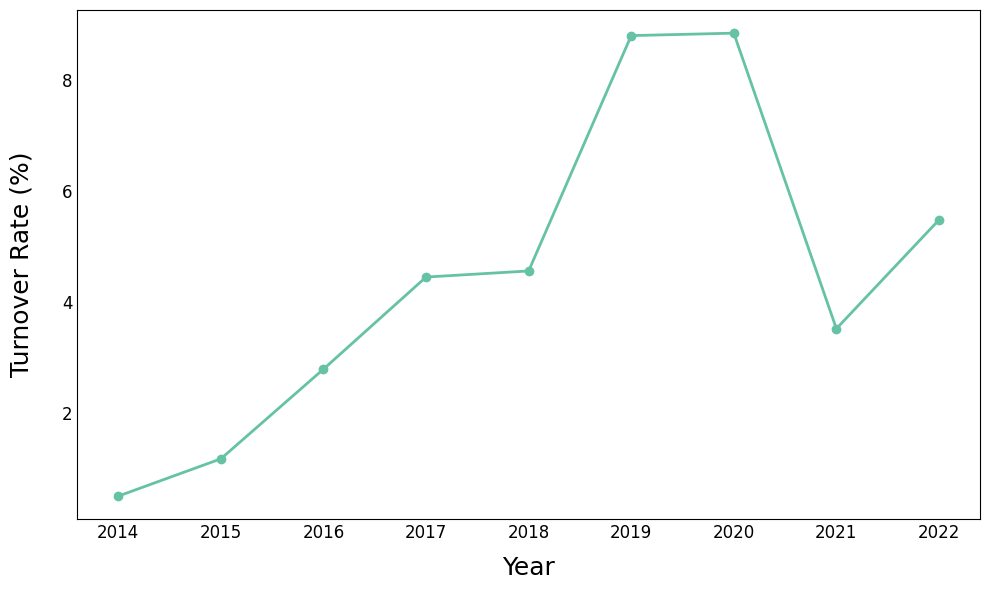

In [2]:
df['DateofHire'] = pd.to_datetime(df['DateofHire'])
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'])
df['TerminationYear'] = df['DateofTermination'].dt.year

terminations_per_year = df.groupby('TerminationYear').size()
years = range(int(df['DateofHire'].dt.year.min()), int(df['DateofTermination'].dt.year.max()) + 1)
headcount_start_year = {}
for year in years:
    start_of_year = pd.Timestamp(f"{year}-01-01")
    employees_active = df[
        (df['DateofHire'] < start_of_year) &
        ((df['DateofTermination'].isna()) | (df['DateofTermination'] >= start_of_year))
    ]
    headcount_start_year[year] = len(employees_active)

headcount_series = pd.Series(headcount_start_year)
turnover_rate = (terminations_per_year / headcount_series) * 100
turnover_rate = turnover_rate.dropna()

palette = sns.color_palette("Set2", n_colors=2)

plt.figure(figsize=(10, 6))
plt.plot(turnover_rate.index, turnover_rate.values, marker='o', color=palette[0], linewidth=2)

ax = plt.gca()
ax.grid(False)
ax.tick_params(axis='x', length=0, labelsize=12)
ax.tick_params(axis='y', length=0, labelsize=12)

plt.xlabel("Year", fontsize=18, labelpad=10)
plt.ylabel("Turnover Rate (%)", fontsize=18, labelpad=20)

plt.tight_layout()
plt.show()

## Self-reported reasons

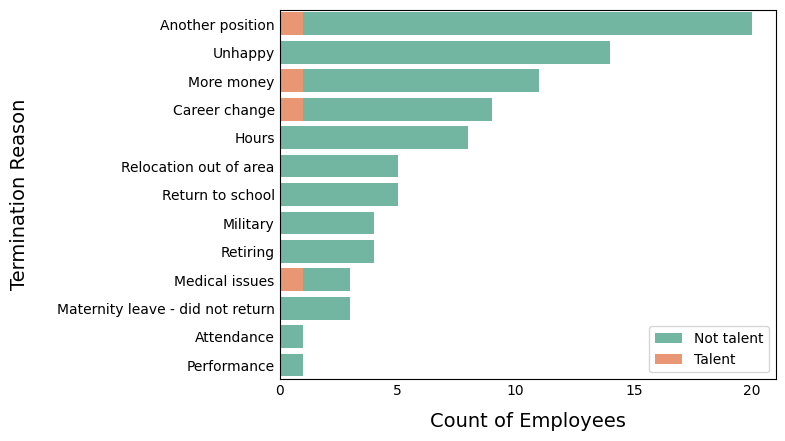

In [3]:
df["TermReason"] = df["TermReason"].astype(str).str.capitalize()

term = df[df["Termd"] == 1]
ct = pd.crosstab(term["TermReason"], [term["EmploymentStatus"], term["is_talent"]])

vol_counts = ct["Voluntarily Terminated"].fillna(0)
vol_counts["Total"] = vol_counts[0] + vol_counts[1]
vol_counts = vol_counts[vol_counts["Total"] > 0].sort_values("Total", ascending=False)

palette = sns.color_palette("Set2", n_colors=2)

sns.barplot(x=vol_counts["Total"], y=vol_counts.index, color=palette[0], label="Not talent")
sns.barplot(x=vol_counts[1], y=vol_counts.index, color=palette[1], label="Talent")

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

ax.grid(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

plt.xlabel("Count of Employees", fontsize=14, labelpad=10)
plt.ylabel("Termination Reason", fontsize=14, labelpad=20)

plt.legend()
plt.show()

## Statistically significant features

In [ ]:
numeric_features = [
    'CarOpp', 'OrgIden', 'ProjSelf', 'Trust', 'ProjColl', 
    'TeamIden', 'ProjLead', 'AIConf', 'PsySafe', 'Feedback', 
    'Network', 'AIUse', 'SpecialProjectsCount', 'TrainHours', 
    'PerfScore', 'Salary', 'Absences', 'JobStr', 'EmpSatisfaction', 'WLF', 'EngagementSurvey', 'DaysLateLast30'
]

categorical_features = [
    'MaritalDesc', 'RaceDesc', 'RecruitmentSource', 'Remote', 
    'TechLev', 'ManPos', 'InnoCont'
]

target_map = {'Active': 'Active', 'Voluntarily Terminated': 'Terminated'}
df_filtered = df[df['EmploymentStatus'].isin(target_map.keys())].copy()
df_filtered['Status'] = df_filtered['EmploymentStatus'].map(target_map)

active = df_filtered[df_filtered['Status'] == 'Active']
terminated = df_filtered[df_filtered['Status'] == 'Terminated']

significance_results = []

for col in numeric_features:
    if col in df_filtered.columns:
        a = active[col].dropna()
        t = terminated[col].dropna()
        
        mean_a = a.mean()
        mean_t = t.mean()
        diff = mean_a - mean_t
        
        t_stat, p_val = stats.ttest_ind(a, t, equal_var=False)
        
        significance_results.append({
            "Feature": col,
            "Type": "Numeric",
            "Test_Used": "Welch t-test",
            "P_Value": p_val,
            "Significance": "Significant" if p_val < 0.05 else "Not Significant",
            "Effect_Direction": "Higher in Active" if diff > 0 else "Higher in Terminated",
            "Note": f"Mean Diff: {diff:.2f}"
        })

for col in categorical_features:
    if col in df_filtered.columns:
        contingency_table = pd.crosstab(df_filtered[col], df_filtered['Status'])
        
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
        
        significance_results.append({
            "Feature": col,
            "Type": "Categorical",
            "Test_Used": "Chi-Square",
            "P_Value": p_val,
            "Significance": "Significant" if p_val < 0.05 else "Not Significant",
            "Effect_Direction": "N/A (Group Association)",
            "Note": f"Degrees of Freedom: {dof}"
        })

stats_df = pd.DataFrame(significance_results).sort_values("P_Value")

print("### FEATURE SIGNIFICANCE REPORT")
print(stats_df.to_string(index=False))

# stats_df.to_csv("feature_significance_report.csv", index=False)

### FEATURE SIGNIFICANCE REPORT
             Feature        Type    Test_Used      P_Value    Significance        Effect_Direction                  Note
              CarOpp     Numeric Welch t-test 1.872617e-15     Significant        Higher in Active       Mean Diff: 0.92
             OrgIden     Numeric Welch t-test 2.510313e-12     Significant        Higher in Active       Mean Diff: 0.85
            ProjSelf     Numeric Welch t-test 1.439697e-11     Significant        Higher in Active       Mean Diff: 0.87
               Trust     Numeric Welch t-test 1.472010e-11     Significant        Higher in Active       Mean Diff: 0.86
            ProjColl     Numeric Welch t-test 4.384813e-08     Significant        Higher in Active       Mean Diff: 0.70
            TeamIden     Numeric Welch t-test 1.073083e-07     Significant        Higher in Active       Mean Diff: 0.67
            ProjLead     Numeric Welch t-test 1.418527e-07     Significant        Higher in Active       Mean Diff: 0.65
